In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)
gene_trait_df

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1


In [ ]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated/annotations_fillna_ukbgym.parquet -o /home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet

anno = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")

min_range = -2000
max_range = +0

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())) &
        
        # Choose Gene Body
        ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)) &

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Choose VEP consequence
        (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('mobi_disorder_full') == True) &

        # Custom variant class filter
        # (pl.col('relative_cds_position')>=0.5) &

        # Choose regulatory region
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &
        
        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    # ADD TO ANNOTATIONS NOTEBOOK
    # .with_columns(
    #     core_promoter = pl.col('dist_to_tss').abs() <= 50,
    #     encode_annotated = pl.col('not_annotated_in_encode') == False,
    #     encode_eh_pr = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_pels', 'encode_dels']),
    #     encode_all_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca_tf']),
    # )
    .with_columns(
        loftee_disorder = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_curated_disorder_priority']),
        loftee_lip = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'mobi_lip_full']),
        loftee_ted = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'ted_domain']),
        loftee_low_complexity = pl.all_horizontal((pl.col(c) == True) for c in ['loftee_hc', 'low_complexity_domain']),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        # set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)

anno

Error: path "/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet"
already exists but -f/--overwrite was not set


loftee_hc,consequence_start_lost,encode_tf,loftee_disorder,consequence_splice_donor_variant,promoterai,ted_domain,encode_pels,encode_pls,low_complexity_domain,mobi_lip_full,consequence_splice_acceptor_variant,five_prime_utr_variant_consequence_ustop_lost,encode_dels,am_pathogenicity,five_prime_utr_variant_consequence_uaug_lost,five_prime_utr_variant_consequence_uaug_gained,esmscoremissense,consequence_missense_variant,relative_cds_position,loftee_ted,mobi_curated_disorder_priority,pangolin_score,loftee_low_complexity,loftee_lip,loftee_lc,absplice2_max,abexp_abs_max,consequence_synonymous_variant,gpn_score,id,five_prime_utr_variant_consequence_ustop_gained,verphylop,region,consequence_frameshift_variant,delta_score,consequence_stop_lost,consequence_stop_gained,cadd_raw,score_pai3d
i8,i8,bool,bool,i8,f32,bool,bool,bool,bool,bool,i8,u8,bool,f32,u8,u8,f32,i8,f32,bool,bool,f32,bool,bool,i8,f32,f32,i8,f32,str,u8,f32,str,i8,f32,i8,i8,f32,f32
0,0,false,false,0,0.0,true,false,false,false,true,0,0,false,0.6793,0,0,-6.18,1,0.38,false,false,0.01,false,false,0,0.002202,0.145382,0,-6.13,"""chr15:51688397:G:A""",0,10.541,"""ENSG00000104112""",0,0.0,0,0,5.221107,0.835758
0,0,false,false,0,0.0,false,false,false,false,false,0,0,false,0.3752,0,0,-4.235,1,0.6,false,false,0.0,false,false,0,0.009521,0.067689,0,-8.47,"""chr2:73455162:C:G""",0,4.069,"""ENSG00000116127""",0,0.0,0,0,4.401463,0.0
0,0,false,false,0,0.0,true,false,false,false,true,0,0,false,0.1793,0,0,-1.937,1,0.52,false,false,0.08,false,false,0,0.002284,0.085274,0,-8.78,"""chr9:35711346:T:A""",0,7.063,"""ENSG00000137076""",0,0.14,0,0,3.622959,0.749405
0,0,false,false,0,0.0,false,true,false,false,false,0,0,false,0.0,0,0,-5.376,1,0.12,false,false,0.0,false,false,0,0.000481,0.110739,0,-5.86,"""chr5:42808215:C:T""",0,4.639,"""ENSG00000250722""",0,0.0,0,0,4.110966,0.0
0,0,false,false,0,0.0,false,true,false,false,false,0,0,false,0.0648,0,0,-4.004,1,0.19,false,false,0.0,false,false,0,0.000033,0.0,0,-0.09,"""chr11:67522634:G:A""",0,-0.082,"""ENSG00000167791""",0,0.0,0,0,0.508567,0.288076
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,false,false,0,0.0325,false,false,false,false,false,0,0,false,0.1351,0,0,-3.345,1,0.64,false,false,0.0,false,false,0,0.000432,0.083404,0,-5.21,"""chr9:120824523:A:G""",0,6.47,"""ENSG00000095261""",0,0.0,0,0,2.803695,0.527511
0,0,false,false,0,0.0,true,false,false,false,false,0,0,true,0.966,0,0,-10.874,1,0.81,false,false,0.05,false,false,0,0.002248,0.15466,0,-9.18,"""chr7:143394335:C:A""",0,1.5,"""ENSG00000146904""",0,0.11,0,0,4.196481,0.858519
0,0,false,false,0,0.0,true,false,false,false,false,0,0,true,0.5679,0,0,-5.091,1,0.36,false,false,0.0,false,false,0,0.00032,0.112486,0,-5.9,"""chr8:2085329:T:C""",0,8.386,"""ENSG00000036448""",0,0.0,0,0,3.701118,0.725551


In [4]:

# selected_categories = ['vep_consequences'] # VEP CDS consequences
# selected_categories = ['plof_consequences'] # VEP plof consequences
# selected_categories = ['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS
# selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['splicing', 'conservation', 'regulatory_nondir', 'genetic_diversity'] # non coding
# selected_categories = ['encode_regions'] # encode regions
# selected_categories = ['encode_custom'] # encode regions custom
# selected_categories = ['conservation', 'regulatory_nondir', 'genetic_diversity'] # 5UTR

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].unique().to_list()

# # Load fillna annotations
# anno_fillna = pl.scan_parquet("/home/dnanexus/data_dir/annotations_fillna_ukbgym.parquet")
# fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

# anno_fillna_melted = (
#     anno_fillna
#     .select(['id', 'region'] + list(fillna_cols))
#     .join(
#         anno.select(['id', 'region']).lazy(), 
#         on=['id', 'region'], 
#         how='semi'
#     )
#     .unpivot(
#         index=["id", "region"],
#         on=list(fillna_cols),
#         variable_name="annotation",
#         value_name="annotation_is_na"
#     )
#     .filter(
#         pl.col('annotation_is_na') == False
#     )
#     .with_columns(
#         annotation = pl.col('annotation').str.replace('_is_na$', '')
#     )
#     # .collect(engine='streaming')
# )

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr15:51688397:G:A""","""ENSG00000104112""","""ted_domain""",1.0
"""chr2:73455162:C:G""","""ENSG00000116127""","""ted_domain""",0.0
"""chr9:35711346:T:A""","""ENSG00000137076""","""ted_domain""",1.0
"""chr5:42808215:C:T""","""ENSG00000250722""","""ted_domain""",0.0
"""chr11:67522634:G:A""","""ENSG00000167791""","""ted_domain""",0.0
…,…,…,…
"""chr9:120824523:A:G""","""ENSG00000095261""","""mobi_lip_full""",0.0
"""chr7:143394335:C:A""","""ENSG00000146904""","""mobi_lip_full""",0.0
"""chr8:2085329:T:C""","""ENSG00000036448""","""mobi_lip_full""",0.0


In [5]:
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet -o /home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet

appv = pl.scan_parquet("/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [7]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- 2. Build the main lazy query plan step-by-step ---
# Start by filtering 'appv', then join everything together. Every operation returns another LazyFrame.
final_lazy_plan = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    .join(anno_ids_lazy, on="id", how="semi")

    # B. Join the other two dataframes
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )

    # C. Apply the ranking (window function) lazily
    .with_columns(
        pl.col(c)
        .rank("max")
        .over(["region", "phenotype", "annotation"])
        .alias(f"{c}_rank")
        for c in ['annotation_score', 'mean_pheno_value']
    )

    # D. Apply the group_by and aggregation lazily
    # .group_by(["region", "gene_name", "phenotype", "annotation"])
    .group_by(["region", "phenotype", "annotation"])
    .agg(
        n_variants = pl.col("id").count(),
        correlation = pl.when(
            (pl.col("annotation_score_rank").n_unique() > 1) & 
            (pl.col("mean_pheno_value_rank").n_unique() > 1)
        )
        .then(
            pl.corr("annotation_score_rank", "mean_pheno_value_rank", propagate_nans=True)
        )
        .otherwise(None) # None maps to NaN for float columns
    )

    .filter(pl.col('annotation')!='loftee_hc')
    .select(["region", "phenotype", "annotation", "n_variants", "correlation"])
    
    .drop_nans().drop_nulls()
    
    # --- 3. Execute the ENTIRE plan at once ---
    .collect(engine='streaming')
)

# --- 4. Join with beta directions and annotation directions ---
correlation_df = (
    final_lazy_plan
    
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gene_trait_df,
        on=['region', 'phenotype'],
    )
    .with_columns(
        corr_beta = pl.col('correlation')*pl.col('loftee_corr_dir')*pl.col('annotation_dir') 
    )
    .with_columns(
        corr_beta_rescaled = (pl.col('corr_beta')/pl.col('loftee_corr'))*pl.col('loftee_corr_dir')
    )
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (1794, 14)


region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64
"""ENSG00000197969""","""mean_sphered_cell_volume_int""","""low_complexity_domain""",1253,0.010123,"""#FF9933""","""Low complexity domain""",1,0.002462,-0.0372,0.0372,-1.0,-0.010123,-0.272139
"""ENSG00000164362""","""mean_corpuscular_volume_int""","""mobi_lip_full""",437,-0.07342,"""#1E90FF""","""LIP domain""",1,0.005039,0.088094,0.088094,1.0,-0.07342,-0.833434
"""ENSG00000115808""","""mean_platelet_thrombocyte_volu…","""low_complexity_domain""",397,-0.135082,"""#FF9933""","""Low complexity domain""",1,0.049246,0.150124,0.150124,1.0,-0.135082,-0.899802
"""ENSG00000113658""","""standing_height_int""","""ted_domain""",148,-0.137736,"""#2E8B57""","""Structured Domain""",1,0.002463,-0.130233,0.130233,-1.0,0.137736,1.057612
"""ENSG00000099875""","""standing_height_int""","""mobi_lip_full""",297,-0.069603,"""#1E90FF""","""LIP domain""",1,0.033081,0.094681,0.094681,1.0,-0.069603,-0.735135
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000204217""","""standing_height_int""","""low_complexity_domain""",386,0.019634,"""#FF9933""","""Low complexity domain""",1,0.00108,-0.050002,0.050002,-1.0,-0.019634,-0.392665
"""ENSG00000108021""","""forced_vital_capacity_fvc_best…","""low_complexity_domain""",916,0.061208,"""#FF9933""","""Low complexity domain""",1,0.01254,-0.042699,0.042699,-1.0,-0.061208,-1.433478
"""ENSG00000017427""","""standing_height_int""","""mobi_curated_disorder_priority""",46,-0.009724,"""#E31A1C""","""Disordered domain""",1,0.047538,-0.23081,0.23081,-1.0,0.009724,0.042131


In [8]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

# filt_corr_df = correlation_df.filter(pl.col("n_variants") > 10) # Select genes with more than 10 variants
filt_corr_df = correlation_df.filter(pl.col("n_variants") > 100)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,corr_beta_rescaled,n_annotations
str,str,str,u64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000164362""","""mean_corpuscular_volume_int""","""mobi_lip_full""",437,-0.07342,"""#1E90FF""","""LIP domain""",1,0.005039,0.088094,0.088094,1.0,-0.07342,-0.833434,4
"""ENSG00000270647""","""forced_vital_capacity_fvc_int""","""mobi_lip_full""",293,0.06822,"""#1E90FF""","""LIP domain""",1,0.027621,-0.120272,0.120272,-1.0,-0.06822,-0.567216,4
"""ENSG00000118762""","""cystatin_c_int""","""mobi_curated_disorder_priority""",403,-0.006945,"""#E31A1C""","""Disordered domain""",1,6.5048e-17,0.17994,0.17994,1.0,-0.006945,-0.038596,4
"""ENSG00000116478""","""sitting_height_int""","""mobi_curated_disorder_priority""",160,-0.01281,"""#E31A1C""","""Disordered domain""",1,0.037007,-0.029678,0.029678,-1.0,0.01281,0.431644,4
"""ENSG00000105610""","""mean_corpuscular_haemoglobin_i…","""mobi_lip_full""",178,0.085848,"""#1E90FF""","""LIP domain""",1,9.8993e-24,-0.291131,0.291131,-1.0,-0.085848,-0.294876,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ENSG00000107282""","""body_mass_index_bmi_int""","""low_complexity_domain""",425,0.002312,"""#FF9933""","""Low complexity domain""",1,0.00104,0.118686,0.118686,1.0,0.002312,0.019483,4
"""ENSG00000078142""","""total_protein_int""","""ted_domain""",304,-0.051128,"""#2E8B57""","""Structured Domain""",1,0.013046,0.118901,0.118901,1.0,-0.051128,-0.43,4
"""ENSG00000005961""","""platelet_count_int""","""mobi_curated_disorder_priority""",454,0.011868,"""#E31A1C""","""Disordered domain""",1,2.0648e-9,-0.174005,0.174005,-1.0,-0.011868,-0.068207,4


In [9]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


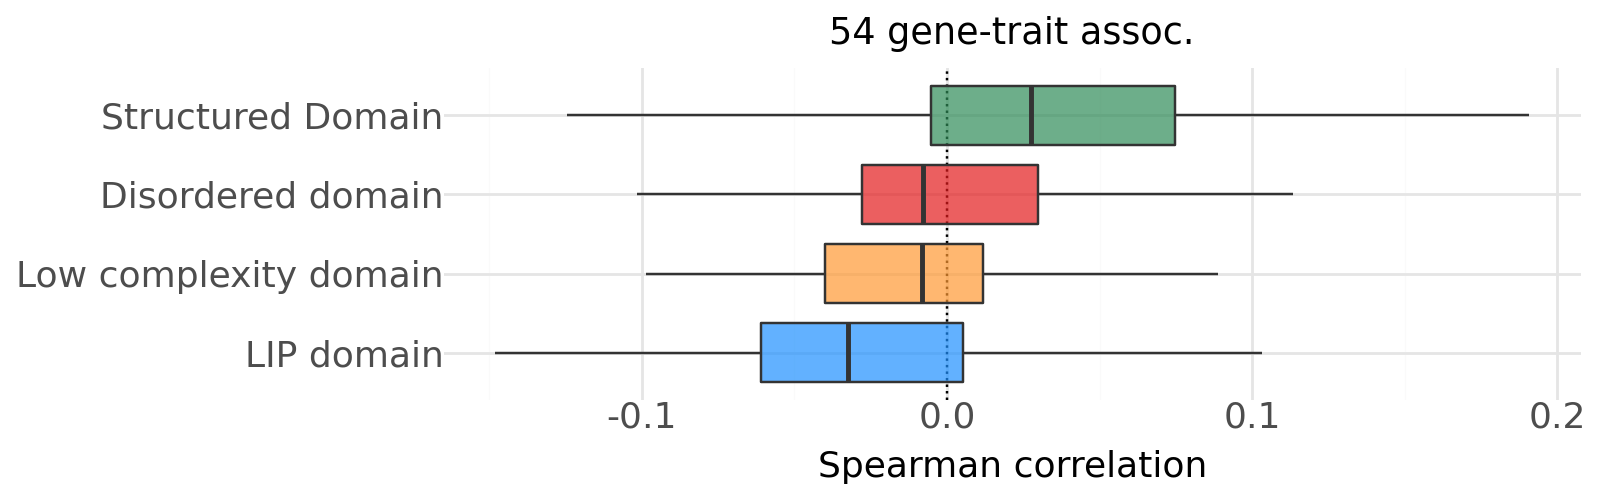

In [10]:
# Prepare for plotting
plotting_col = 'corr_beta'
# plotting_col = 'corr_beta_rescaled'

dashed_line_value = 1 if 'rescaled' in plotting_col else 0

med_df = filt_corr_df.drop_nans().group_by("annotation").agg(
    median_corr_beta = pl.col(plotting_col).median(),
)

corr_pd = med_df.join(filt_corr_df, on='annotation').to_pandas()

corr_pd['label'] = pd.Categorical(
    corr_pd['label'],
    categories=corr_pd.sort_values('median_corr_beta', ascending=True)['label'].unique(),
    ordered=True
)

color_dict = dict(zip(corr_pd['annotation'], corr_pd['color']))

# Plot
(
    ggplot(corr_pd, aes(x="label", y=plotting_col, fill="annotation"))
    + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    # + geom_boxplot(alpha=0.7)
    + geom_boxplot(alpha=0.7, outlier_shape=None)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{corr_pd[['region', 'phenotype']].drop_duplicates().shape[0]} gene-trait assoc."
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pd['annotation'].nunique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [11]:
med_df.sort('median_corr_beta')

annotation,median_corr_beta
str,f64
"""mobi_lip_full""",-0.032492
"""low_complexity_domain""",-0.008225
"""mobi_curated_disorder_priority""",-0.007951
"""ted_domain""",0.027507


In [12]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_273094/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
"""mobi_lip_full""","""ted_domain""",54,341.0,0.000546
"""low_complexity_domain""","""ted_domain""",54,450.0,0.011786
"""mobi_curated_disorder_priority""","""ted_domain""",54,482.0,0.024899
